In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr  # ✅ 改用 pearsonr 計算相關係數

In [4]:
df = pd.read_csv("Project for pand.csv")

In [148]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(context="talk", style="whitegrid")
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.edgecolor": "#E5E7EB",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#E5E7EB",
    "grid.linewidth": 0.6,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "#E5E7EB",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
# 推薦用色
NAVY = "#0C2C56"; TEAL = "#0F766E"; SILVER = "#C4CED4"; CORAL = "#FF7F50"

In [82]:
selected_cols = [
    "launch_angle_avg",
    "sweet_spot_percent",
    "barrel_batted_rate",
    "hard_hit_percent",
    "exit_velocity_avg",
    "pull_percent",
    "flyballs_percent",
    "on_base_plus_slg",
    "launch_angle_avg" 
]

In [43]:
for c in selected_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

In [44]:
corr_df = df[selected_cols].dropna()

In [45]:
corr_matrix = corr_df.corr()

In [46]:
target = "on_base_plus_slg"
corr_with_ops = corr_matrix[target].sort_values(ascending=False)

print("=== 各項指標與 On Base Plus Slg (OPS) 的相關係數 ===")
print(corr_with_ops)

=== 各項指標與 On Base Plus Slg (OPS) 的相關係數 ===
on_base_plus_slg      1.000000
barrel_batted_rate    0.565338
exit_velocity_avg     0.515083
hard_hit_percent      0.511521
sweet_spot_percent    0.369690
flyballs_percent      0.241997
launch_angle_avg      0.117607
pull_percent          0.109655
Name: on_base_plus_slg, dtype: float64


In [47]:
corr_plot = corr_with_ops.drop("on_base_plus_slg")


In [48]:
plt.figure(figsize=(8, 5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

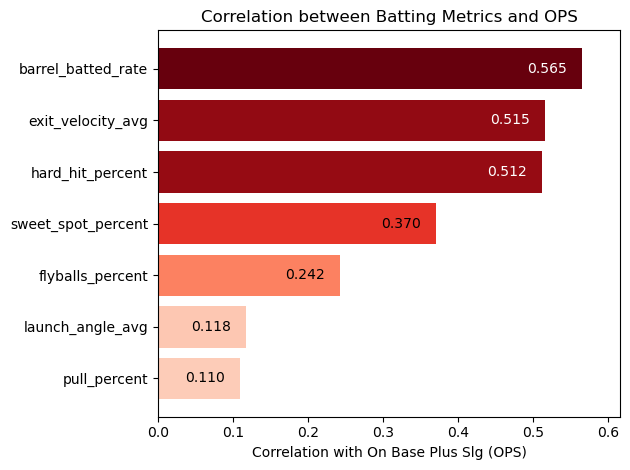

In [53]:
bars = plt.barh(corr_plot.index, corr_plot.values, color=plt.cm.Reds(corr_plot.values / max(corr_plot.values)))
for bar in bars:
    width = bar.get_width()
    color = "white" if width > 0.4 else "black"
    plt.text(
        width - 0.02,  # 稍微向左內縮
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        ha="right",
        va="center",
        color=color,
        fontsize=10
    )

# === 動態調整右邊界 ===
xmax = max(corr_plot.values) + 0.05  # 最大值 + 0.05 當作右邊界
plt.xlim(0, xmax)

# 圖表標題與軸標籤
plt.title("Correlation between Batting Metrics and OPS")
plt.gca().invert_yaxis()  # 最高相關顯示在最上面
plt.tight_layout()
plt.show()

In [83]:
df['barrel_batted_rate'] = df['barrel_batted_rate'] / 100
df['hard_hit_percent'] = df['hard_hit_percent'] / 100
df['launch_angle_avg '] = df['launch_angle_avg '] / 100

KeyError: 'launch_angle_avg '

In [75]:
cols = ["barrel_batted_rate", "hard_hit_percent", "launch_angle_avg ", "on_base_plus_slg"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=cols)

In [68]:
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(10, 4))

<Figure size 1000x400 with 0 Axes>

<Figure size 1000x400 with 0 Axes>

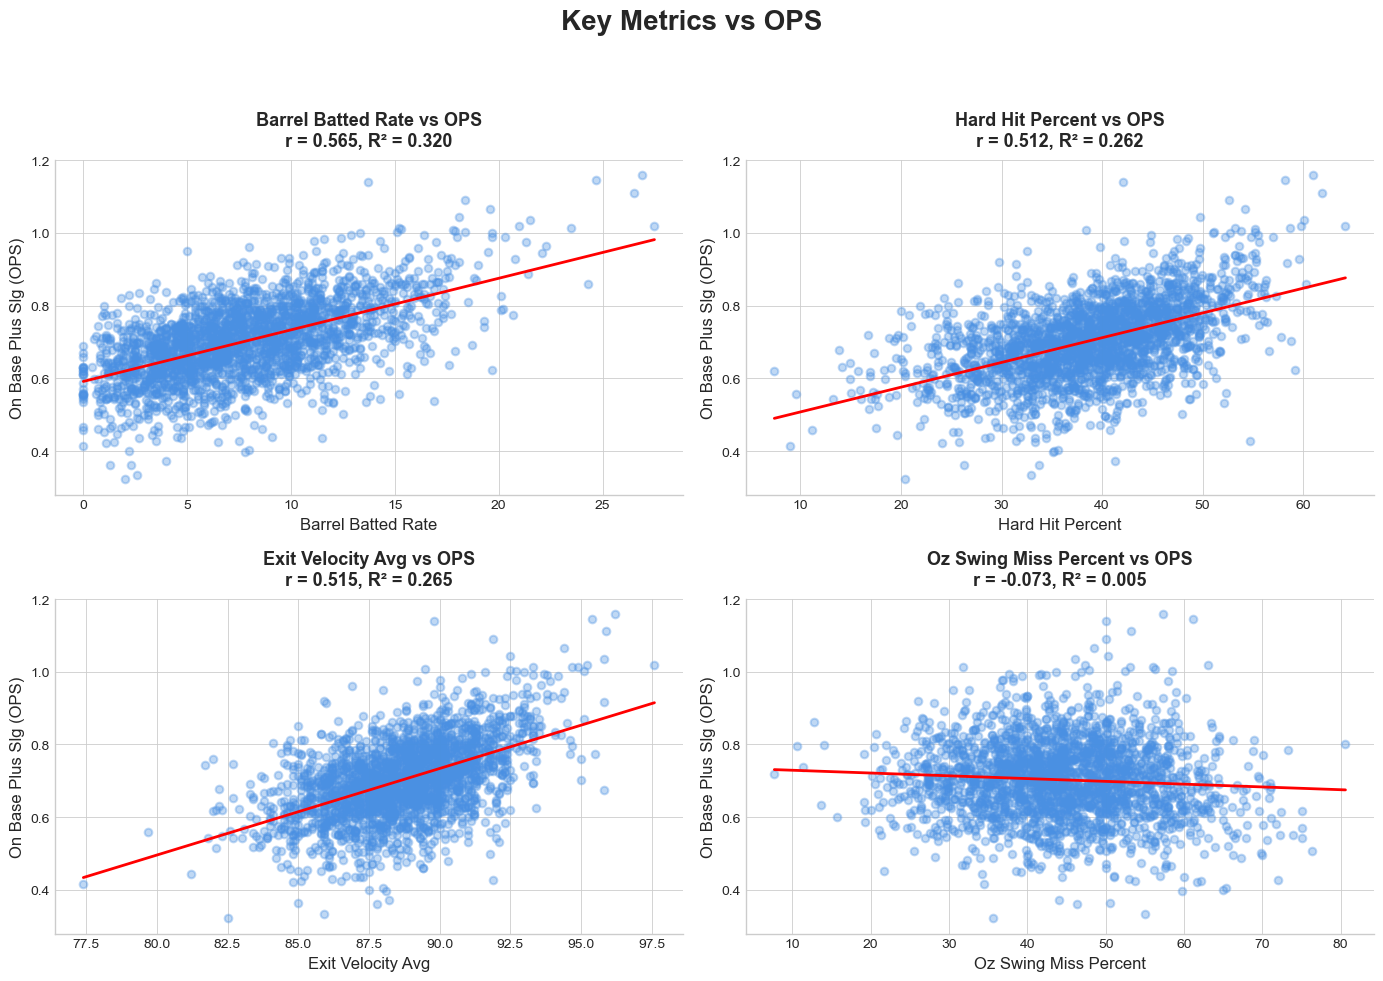

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# === 讀資料 ===
df = pd.read_csv("Project for pand.csv")

# 清理欄位名稱
df.columns = df.columns.str.strip()

# === 指標與目標變數 ===
features = [
    "barrel_batted_rate",
    "hard_hit_percent",
    "exit_velocity_avg",
    "oz_swing_miss_percent"   # ✅ 新增這個變數
]
target = "on_base_plus_slg"

# 確保為數值型態並移除缺失值
df[features + [target]] = df[features + [target]].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=features + [target])

# === 畫圖設定 ===
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # 攤平成一維索引
fig.suptitle("Key Metrics vs OPS", fontsize=20, weight="bold")

# === 繪製每個 feature 的散點圖與回歸線 ===
for i, feature in enumerate(features):
    x = df[feature]
    y = df[target]

    # 線性回歸
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value ** 2

    # 散點
    axes[i].scatter(x, y, alpha=0.35, s=30, color="#4A90E2")

    # 回歸線
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    axes[i].plot(x_line, y_line, color="red", linewidth=2)

    # 標題
    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs OPS\n"
        f"r = {r_value:.3f}, R² = {r2:.3f}",
        fontsize=13, weight="bold", pad=10
    )

    # 軸標籤
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=12)
    axes[i].set_ylabel("On Base Plus Slg (OPS)", fontsize=12)
    axes[i].tick_params(axis="both", labelsize=10)

# === 如果 feature 不足 4 個，關閉多餘子圖（這裡剛好4張會全用到）===
for j in range(len(features), len(axes)):
    axes[j].axis("off")

# 美化與排版
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

In [59]:
df[['barrel_batted_rate', 'hard_hit_percent', 'on_base_plus_slg']].describe()

,barrel_batted_rate,hard_hit_percent,on_base_plus_slg
count,2309.000000,2309.000000,2309.000000
mean,7.850152,38.687657,0.702825
std,4.239754,7.997964,0.106368
min,0.000000,7.400000,0.322000
25%,4.700000,33.500000,0.633000
50%,7.400000,39.000000,0.701000
75%,10.500000,44.100000,0.772000
max,27.500000,64.200000,1.159000


In [64]:
from scipy.stats import pearsonr

r, p = pearsonr(df[metric], df["on_base_plus_slg"])
r2 = r ** 2

Text(0.5, 1.0, 'Hard_Hit_Percent vs OPS\nr = 0.512, R² = 0.262')

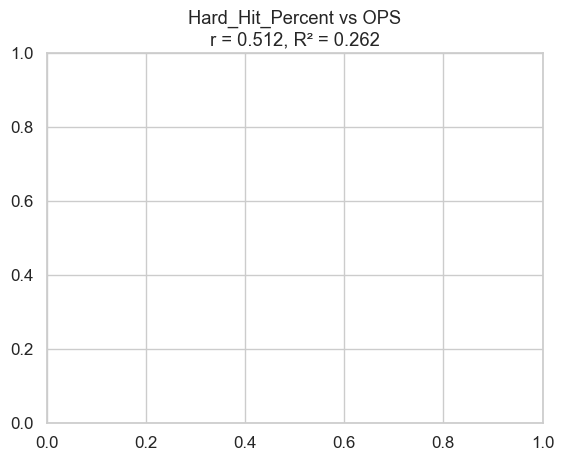

In [65]:
plt.title(f"{metric.title()} vs OPS\nr = {r:.3f}, R² = {r2:.3f}")

In [85]:
corr_with_hardhit = df.select_dtypes(include=["float64"]).corr()['on_base_plus_slg'].sort_values(ascending=False)

print("=== 與 Hard Hit Percent 高度相關的變數 ===")
print(corr_with_hardhit)

=== 與 Hard Hit Percent 高度相關的變數 ===
on_base_plus_slg         1.000000
woba                     0.993496
slg_percent              0.961864
on_base_percent          0.848487
xwoba                    0.828020
xslg                     0.795154
batting_avg              0.790985
xiso                     0.687851
barrel_batted_rate       0.565338
avg_hyper_speed          0.527307
avg_best_speed           0.517715
exit_velocity_avg        0.515083
hard_hit_percent         0.511521
blasts_swing             0.508561
blasts_contact           0.477101
sweet_spot_percent       0.369690
fast_swing_rate          0.361664
bb_percent               0.345878
avg_swing_speed          0.335666
solidcontact_percent     0.278816
flyballs_percent         0.241997
avg_swing_length         0.153312
launch_angle_avg         0.117607
pull_percent             0.109655
attack_angle             0.089723
iz_contact_percent       0.055247
z_swing_percent          0.039355
ideal_angle_rate         0.033775
z_swing_miss_

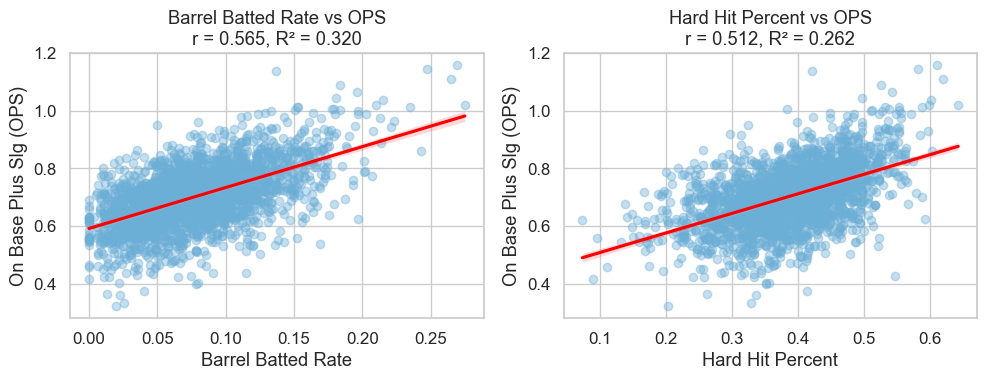

In [120]:
metrics = ["barrel_batted_rate", "hard_hit_percent"]  # ✅ 去掉多餘空白
target = "on_base_plus_slg"

# 只保留需要欄位並轉成數值
use_cols = metrics + [target]
df_plot = df[use_cols].copy()
df_plot = df_plot.apply(pd.to_numeric, errors="coerce")

# 對可能是百分比的欄位做「自動/保守」修正：若平均值 > 1 就視為 0~100%，除以 100
for c in ["barrel_batted_rate", "hard_hit_percent"]:
    if c in df_plot and df_plot[c].mean(skipna=True) > 1:
        df_plot[c] = df_plot[c] / 100.0

# 去除缺值
df_plot = df_plot.dropna(subset=use_cols)

# 畫圖
sns.set(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(15, 4))

for i, metric in enumerate(metrics, start=1):
    plt.subplot(1, 3, i)
    sns.regplot(
        x=metric, y=target, data=df_plot,
        scatter_kws={'alpha': 0.4, 'color': '#6BAED6'},  # 淺藍點
        line_kws={'color': 'red'}
    )
    r, p = pearsonr(df_plot[metric], df_plot[target])
    r2 = r**2
    plt.title(f"{metric.replace('_',' ').title()} vs OPS\nr = {r:.3f}, R² = {r2:.3f}")
    plt.xlabel(metric.replace('_',' ').title())
    plt.ylabel("On Base Plus Slg (OPS)")

plt.tight_layout()
plt.show()

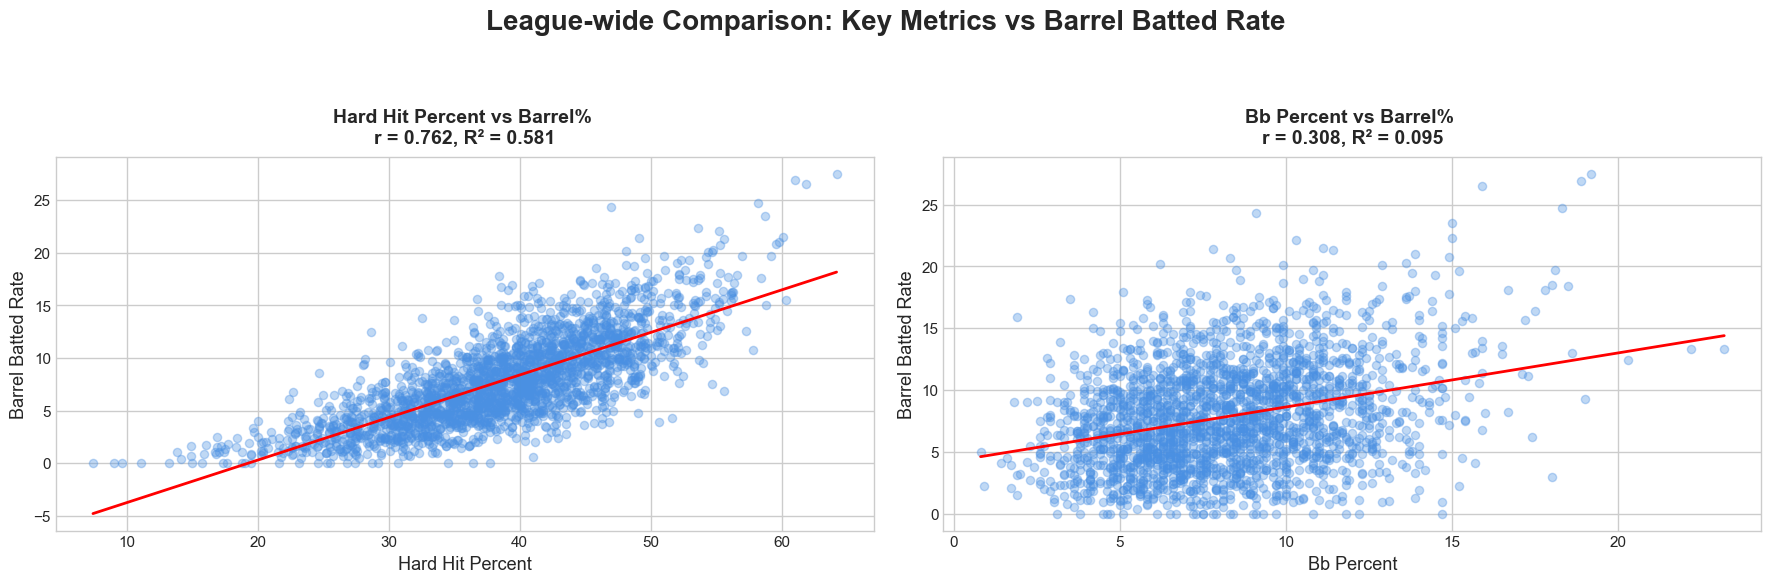

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# 讀資料
df = pd.read_csv("Project for pand.csv")

# 清理欄位名稱（去除多餘空白）
df.columns = df.columns.str.strip()

# 選擇要比較的指標（可自行替換/新增）
features = ["hard_hit_percent",  "bb_percent"]
target = "barrel_batted_rate"

# 轉成數值型、清理缺值
df[features + [target]] = df[features + [target]].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=features + [target])

# --- 畫圖 ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, len(features), figsize=(18, 6))
fig.suptitle("League-wide Comparison: Key Metrics vs Barrel Batted Rate", fontsize=20, weight="bold")

for i, feature in enumerate(features):
    x = df[feature]
    y = df[target]

    # 線性回歸
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    r2 = r_value ** 2

    # 散點圖
    axes[i].scatter(x, y, alpha=0.35, s=35, color="#4A90E2")

    # 回歸線
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    axes[i].plot(x_line, y_line, color="red", linewidth=2)

    # 標題與相關係數
    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs Barrel% \n"
        f"r = {r_value:.3f}, R² = {r2:.3f}",
        fontsize=14, weight="bold", pad=10
    )

    # 軸標籤
    axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=13)
    axes[i].set_ylabel("Barrel Batted Rate", fontsize=13)
    axes[i].tick_params(axis="both", labelsize=11)

# 排版優化
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

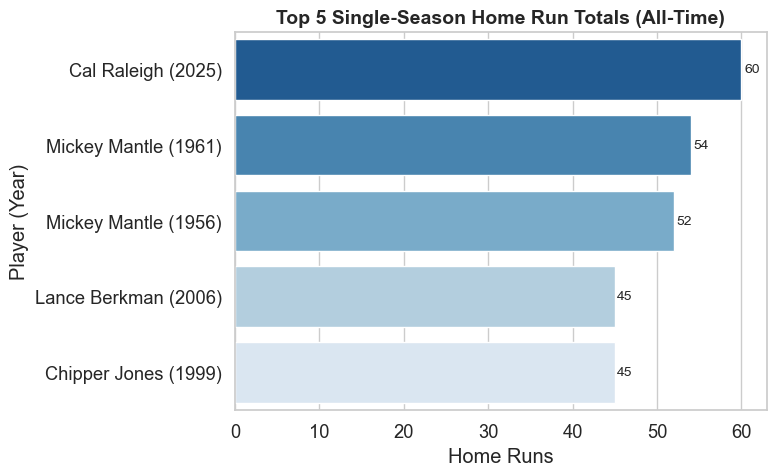

In [88]:
data1 = {
    "Name": ["Cal Raleigh", "Mickey Mantle", "Mickey Mantle", "Lance Berkman", "Chipper Jones"],
    "HR": [60, 54, 52, 45, 45],
    "Season": [2025, 1961, 1956, 2006, 1999],
    "Team": ["SEA", "NYY", "NYY", "HOU", "ATL"]
}
df1 = pd.DataFrame(data1)
df1["Player (Year)"] = df1["Name"] + " (" + df1["Season"].astype(str) + ")"

plt.figure(figsize=(8,5))
sns.barplot(data=df1, x="HR", y="Player (Year)", palette="Blues_r")
plt.title("Top 5 Single-Season Home Run Totals (All-Time)", fontsize=14, weight="bold")
plt.xlabel("Home Runs")
plt.ylabel("Player (Year)")
for i, v in enumerate(df1["HR"]):
    plt.text(v + 0.3, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

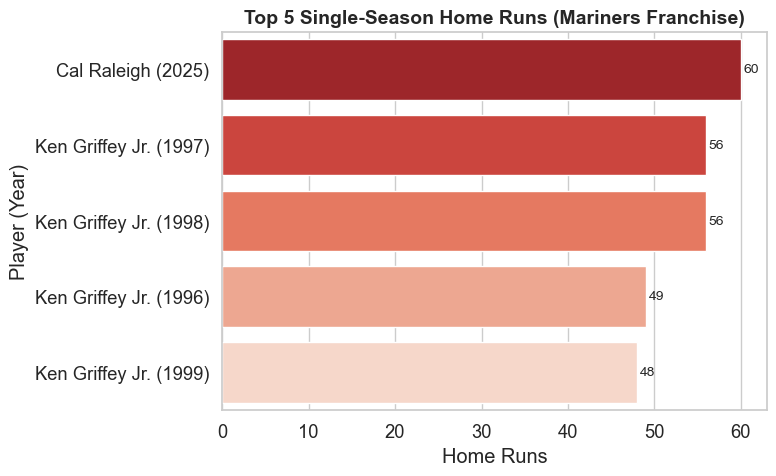

In [89]:
data2 = {
    "Name": ["Cal Raleigh", "Ken Griffey Jr.", "Ken Griffey Jr.", "Ken Griffey Jr.", "Ken Griffey Jr."],
    "HR": [60, 56, 56, 49, 48],
    "Season": [2025, 1997, 1998, 1996, 1999]
}
df2 = pd.DataFrame(data2)
df2["Player (Year)"] = df2["Name"] + " (" + df2["Season"].astype(str) + ")"

plt.figure(figsize=(8,5))
sns.barplot(data=df2, x="HR", y="Player (Year)", palette="Reds_r")
plt.title("Top 5 Single-Season Home Runs (Mariners Franchise)", fontsize=14, weight="bold")
plt.xlabel("Home Runs")
plt.ylabel("Player (Year)")
for i, v in enumerate(df2["HR"]):
    plt.text(v + 0.3, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

on_base_plus_slg         1.000000
avg_swing_length         0.998033
woba                     0.997804
xiso                     0.993311
slg_percent              0.991386
xslg                     0.985073
home_run                 0.979210
oz_swing_miss_percent    0.977206
launch_angle_avg         0.970461
barrel_batted_rate       0.963887
dtype: float64


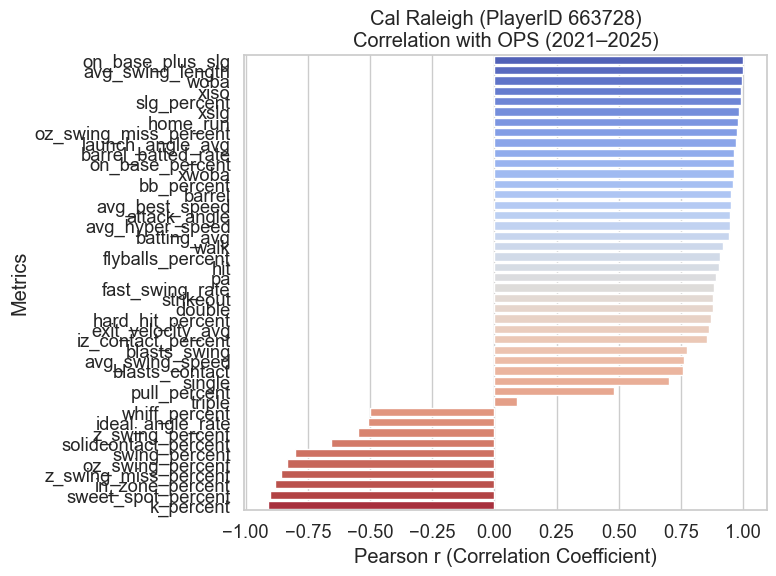

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 讀取資料
df = pd.read_csv("Project for pand.csv")

# 篩選球員 663728
player_df = df[df["player_id"] == 663728].copy()

# 篩選數值欄
numeric_cols = player_df.select_dtypes(include=["float", "int"]).columns

# 移除明顯不相關欄（例如 year、player_id）
exclude_cols = ["player_id", "year"]
corr_cols = [c for c in numeric_cols if c not in exclude_cols]

# 計算與 OPS 的相關性
corrs = player_df[corr_cols].corrwith(player_df["on_base_plus_slg"]).sort_values(ascending=False)

# 顯示前10名
print(corrs.head(10))

# --- 視覺化 ---
plt.figure(figsize=(8,6))
sns.barplot(x=corrs.values, y=corrs.index, palette="coolwarm")
plt.title("Cal Raleigh (PlayerID 663728)\nCorrelation with OPS (2021–2025)")
plt.xlabel("Pearson r (Correlation Coefficient)")
plt.ylabel("Metrics")
plt.tight_layout()
plt.show()

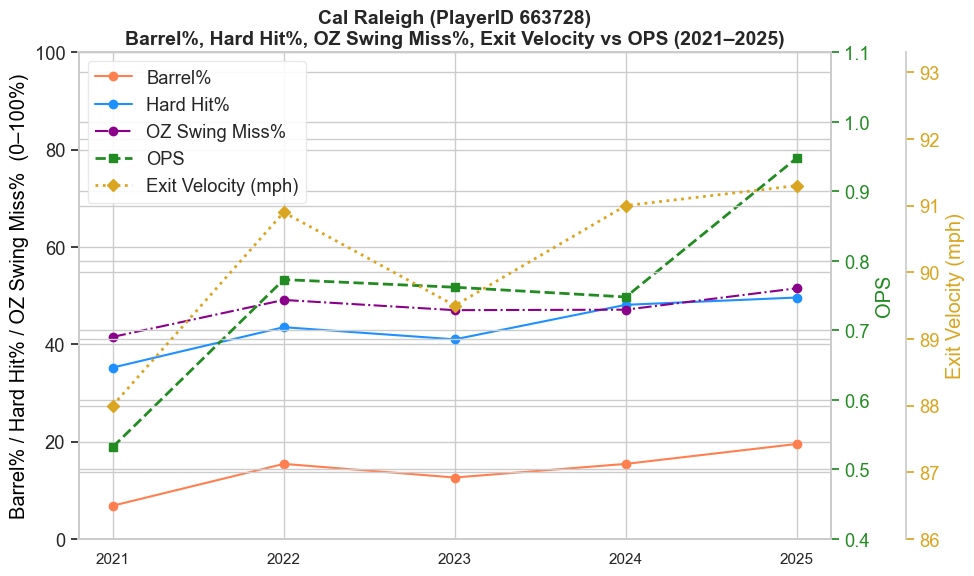

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
df = pd.read_csv("Project for pand.csv")

# Cal Raleigh 2021–2025
player_df = df[(df["player_id"] == 663728) & df["year"].between(2021, 2025)].copy()
cols = ["year", "barrel_batted_rate", "hard_hit_percent", "oz_swing_miss_percent", "exit_velocity_avg", "on_base_plus_slg"]
player_df[cols] = player_df[cols].apply(pd.to_numeric, errors="coerce")

# 百分比欄位：若原檔是 0–100 就除以 100；最後一律用 % 顯示（乘 100 畫圖）
pct_cols = ["barrel_batted_rate", "hard_hit_percent", "oz_swing_miss_percent"]
for c in pct_cols:
    if player_df[c].mean(skipna=True) > 1:      # 原本是 0–100
        player_df[c] = player_df[c] / 100.0

# 給圖用：轉成百分數
plot_df = player_df.copy()
for c in pct_cols:
    plot_df[c] = plot_df[c] * 100.0             # 0–100%

# --- 視覺化 ---
sns.set(style="whitegrid", font_scale=1.2)
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：三條百分比（0–100%）
ax1.plot(plot_df["year"], plot_df["barrel_batted_rate"], marker="o", color="#FF7F50", label="Barrel%")
ax1.plot(plot_df["year"], plot_df["hard_hit_percent"], marker="o", color="#1E90FF", label="Hard Hit%")
ax1.plot(plot_df["year"], plot_df["oz_swing_miss_percent"], marker="o", color="#8B008B", linestyle="-.", label="OZ Swing Miss%")
ax1.set_ylabel("Barrel% / Hard Hit% / OZ Swing Miss%  (0–100%)", color="black")
ax1.set_ylim(0, 100)

# 右軸(1)：OPS
ax2 = ax1.twinx()
line_ops, = ax2.plot(plot_df["year"], plot_df["on_base_plus_slg"], marker="s",
                     color="#228B22", linestyle="--", linewidth=2, label="OPS")
ax2.set_ylabel("OPS", color="#228B22")
ax2.tick_params(axis="y", colors="#228B22")
ax2.set_ylim(0.4, 1.1)

# 右軸(2)：Exit Velocity（第二個右軸，稍微外移）
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.1))   # 往外推一點
line_ev, = ax3.plot(plot_df["year"], plot_df["exit_velocity_avg"], marker="D",
                    color="#DAA520", linestyle=":", linewidth=2, label="Exit Velocity (mph)")
ax3.set_ylabel("Exit Velocity (mph)", color="#DAA520")
ax3.tick_params(axis="y", colors="#DAA520")
# 可依你的資料調整範圍
ev_min = max(60, plot_df["exit_velocity_avg"].min() - 2)
ev_max = min(120, plot_df["exit_velocity_avg"].max() + 2)
ax3.set_ylim(ev_min, ev_max)

# 年份刻度（整數）
ax1.set_xticks(sorted(plot_df["year"].unique()))
ax1.set_xticklabels(plot_df["year"].astype(int), fontsize=11)

# 標題與圖例（合併三個座標軸的圖例）
plt.title("Cal Raleigh (PlayerID 663728)\nBarrel%, Hard Hit%, OZ Swing Miss%, Exit Velocity vs OPS (2021–2025)",
          fontsize=14, weight="bold")
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = [line_ops], ["OPS"]
handles3, labels3 = [line_ev], ["Exit Velocity (mph)"]
plt.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3, loc="upper left", frameon=True)

plt.xlabel("Year", fontsize=12)
plt.tight_layout()
plt.show()

In [96]:
import pandas as pd

# 讀取資料
df = pd.read_csv("Project for pand.csv")

# 篩選球員 663728
player_df = df[df["player_id"] == 663728].copy()
player_df = player_df[player_df["year"].between(2021, 2025)]

# 數值欄位
num_cols = player_df.select_dtypes(include=["float", "int"]).columns
exclude = ["player_id", "year"]
cols = [c for c in num_cols if c not in exclude]

# 1️⃣ 計算與 OPS 的相關係數
corrs = player_df[cols].corrwith(player_df["on_base_plus_slg"]).sort_values(ascending=False)

# 2️⃣ 取 2024、2025 的資料
df_24 = player_df[player_df["year"] == 2024].set_index("player_id")
df_25 = player_df[player_df["year"] == 2025].set_index("player_id")

# 計算變化幅度（2025 - 2024）
diff = (df_25[cols].iloc[0] - df_24[cols].iloc[0]).sort_values(ascending=False)

# 3️⃣ 合併兩項資訊
compare = pd.DataFrame({
    "corr_with_OPS": corrs,
    "change_2025_minus_2024": diff
}).dropna().sort_values("change_2025_minus_2024", ascending=False)

# 顯示最相關且進步最多的前10項
print(compare.head(10))

                  corr_with_OPS  change_2025_minus_2024
pa                     0.891127                    77.0
walk                   0.919662                    27.0
hit                    0.901859                    27.0
home_run               0.979210                    26.0
barrel                 0.950657                    22.0
strikeout              0.878376                    12.0
fast_swing_rate        0.884716                     9.6
pull_percent           0.481504                     9.0
double                 0.877240                     8.0
flyballs_percent       0.907446                     5.1


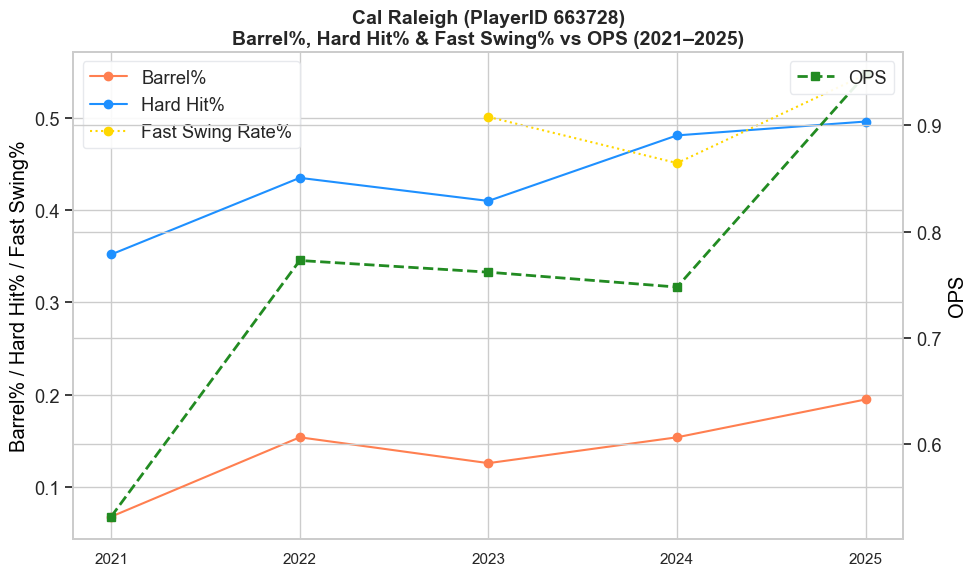

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
df = pd.read_csv("Project for pand.csv")

# 篩選 Cal Raleigh (player_id=663728)
player_df = df[df["player_id"] == 663728].copy()

# 篩選年份 2021–2025
player_df = player_df[player_df["year"].between(2021, 2025)]

# 數值轉換（只留三項 + OPS）
cols = [
    "year",
    "barrel_batted_rate",
    "hard_hit_percent",
    "fast_swing_rate",
    "on_base_plus_slg"
]
player_df[cols] = player_df[cols].apply(pd.to_numeric, errors="coerce")

# 若原始數據為百分比則修正
for c in ["barrel_batted_rate", "hard_hit_percent", "fast_swing_rate"]:
    if player_df[c].mean(skipna=True) > 1:
        player_df[c] = player_df[c] / 100

# --- 視覺化 ---
sns.set(style="whitegrid", font_scale=1.2)
fig, ax1 = plt.subplots(figsize=(10,6))

# 左軸：Barrel%、Hard Hit%、Fast Swing%
ax1.plot(player_df["year"], player_df["barrel_batted_rate"], marker="o", color="#FF7F50", label="Barrel%")
ax1.plot(player_df["year"], player_df["hard_hit_percent"], marker="o", color="#1E90FF", label="Hard Hit%")
ax1.plot(player_df["year"], player_df["fast_swing_rate"], marker="o", color="#FFD700", linestyle=":", label="Fast Swing Rate%")
ax1.set_ylabel("Barrel% / Hard Hit% / Fast Swing%", color="black")

# 右軸：OPS
ax2 = ax1.twinx()
ax2.plot(player_df["year"], player_df["on_base_plus_slg"], marker="s", color="#228B22", linestyle="--", linewidth=2, label="OPS")
ax2.set_ylabel("OPS", color="black")

# ✅ 年份軸修正
ax1.set_xticks(sorted(player_df["year"].unique()))
ax1.set_xticklabels(player_df["year"].astype(int), fontsize=11)

# 標題與圖例
plt.title("Cal Raleigh (PlayerID 663728)\nBarrel%, Hard Hit% & Fast Swing% vs OPS (2021–2025)", fontsize=14, weight="bold")
ax1.legend(loc="upper left", frameon=True)
ax2.legend(loc="upper right", frameon=True)

plt.xlabel("Year")
plt.tight_layout()
plt.show()

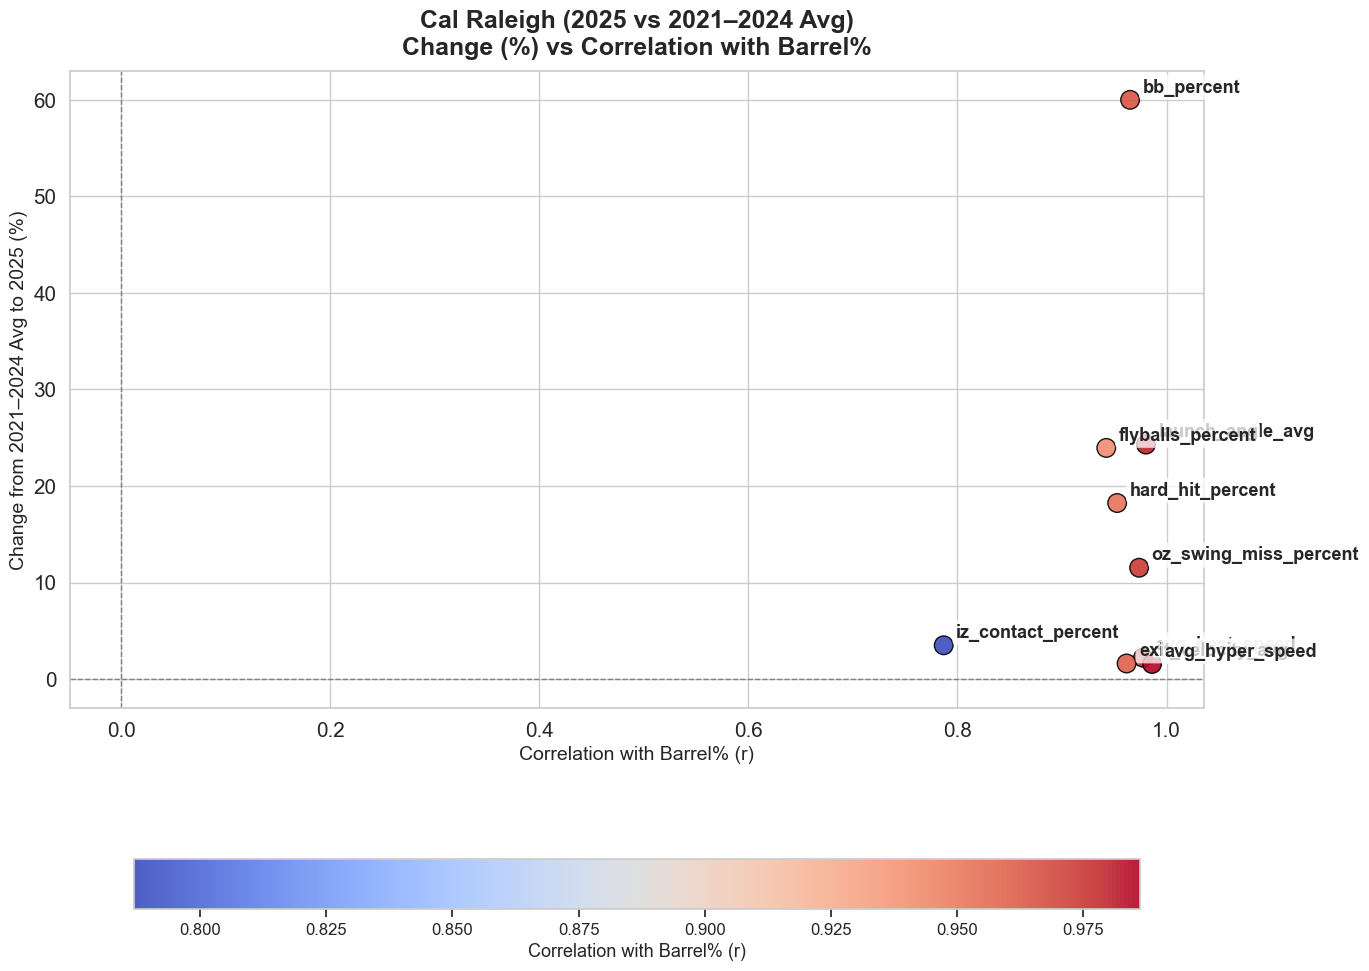

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀檔 & 篩 Cal Raleigh
df = pd.read_csv("Project for pand.csv")
player_df = df[(df["player_id"] == 663728) & df["year"].between(2021, 2025)].copy()

# 數值欄位
num_cols = player_df.select_dtypes(include=["float", "int"]).columns

# 排除不分析欄位（含 barrel_batted_rate 自己）
exclude = [
    "player_id", "year",
    "pa", "walk", "hit", "home_run", "strikeout", "double", "triple", "single",
    "batting_avg", "slg_percent", "on_base_percent", "xslg", "woba", "xwoba",
    "avg_swing_speed", "fast_swing_rate", "blasts_contact", "blasts_swing",
    "avg_swing_length", "attack_angle", "ideal_angle_rate",
    "pull_percent", "barrel", "xiso", "on_base_plus_slg",
    "barrel_batted_rate"      # ✅ 去掉目標本身
]
cols = [c for c in num_cols if c not in exclude]

# --- 平均 vs 2025（百分比變化）
avg_21_24 = player_df[player_df["year"].between(2021, 2024)][cols].mean()
val_2025  = player_df[player_df["year"] == 2025][cols].mean()
delta = ((val_2025 - avg_21_24) / avg_21_24 * 100)

# --- 與 Barrel% 的相關係數（只留正相關）
r = player_df[cols].corrwith(player_df["barrel_batted_rate"])
r = r[r > 0].sort_values(ascending=False)

# --- 合併（只保留同一批指標）
compare = pd.DataFrame({
    "corr_with_barrel": r,
    "change_2025_minus_avg21_24(%)": delta[r.index]
}).dropna().sort_values("change_2025_minus_avg21_24(%)", ascending=False)

# ======== 畫圖 ========
sns.set(style="whitegrid", font_scale=1.35)
fig, ax = plt.subplots(figsize=(14, 10))

pts = ax.scatter(
    compare["corr_with_barrel"],
    compare["change_2025_minus_avg21_24(%)"],
    c=compare["corr_with_barrel"],
    cmap="coolwarm",
    s=180, alpha=0.9, edgecolor="black", linewidth=1
)

# 文字標籤
for i in range(compare.shape[0]):
    ax.text(
        compare["corr_with_barrel"].iloc[i] + 0.012,
        compare["change_2025_minus_avg21_24(%)"].iloc[i] + 0.8,
        compare.index[i],
        fontsize=13, weight="bold",
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", boxstyle="round,pad=0.2")
    )

# 輔助線
ax.axvline(0, color="gray", ls="--", lw=1)
ax.axhline(0, color="gray", ls="--", lw=1)

# ✅ colorbar 改到底部
cbar = fig.colorbar(pts, ax=ax, orientation="horizontal", pad=0.18, fraction=0.06)
cbar.set_label("Correlation with Barrel% (r)", fontsize=13)
cbar.ax.tick_params(labelsize=12)

ax.set_title("Cal Raleigh (2025 vs 2021–2024 Avg)\nChange (%) vs Correlation with Barrel%",
             fontsize=18, weight="bold", pad=12)
ax.set_xlabel("Correlation with Barrel% (r)", fontsize=14)
ax.set_ylabel("Change from 2021–2024 Avg to 2025 (%)", fontsize=14)

ax.margins(x=0.05, y=0.05)
plt.tight_layout()
plt.show()

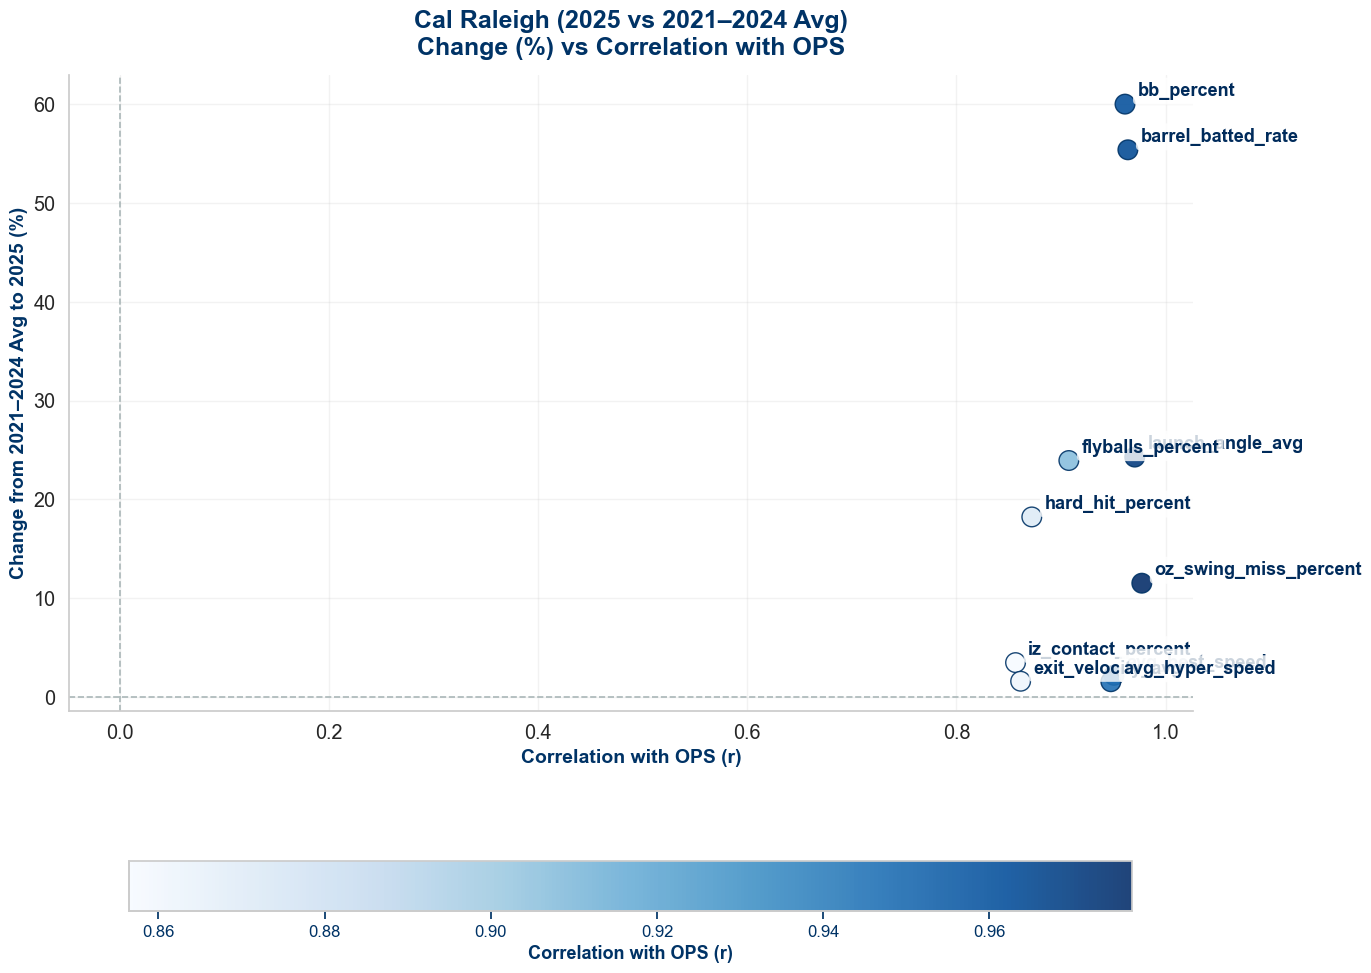

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 讀取資料 ---
df = pd.read_csv("Project for pand.csv")

# --- 篩選 Cal Raleigh ---
player_df = df[df["player_id"] == 663728].copy()
player_df = player_df[player_df["year"].between(2021, 2025)]

# --- 數值欄位 ---
num_cols = player_df.select_dtypes(include=["float", "int"]).columns

# 🧹 排除不分析欄位 ---
exclude = [
    "player_id", "year",
    "pa", "walk", "hit", "home_run", "strikeout", "double", "triple", "single",
    "batting_avg", "slg_percent", "on_base_percent", "xslg", "woba", "xwoba",
    "avg_swing_speed", "fast_swing_rate", "blasts_contact", "blasts_swing",
    "avg_swing_length", "attack_angle", "ideal_angle_rate",
    "pull_percent", "barrel", "xiso", "on_base_plus_slg"
]
cols = [c for c in num_cols if c not in exclude]

# --- 計算平均與變化 ---
df_avg = player_df[player_df["year"].between(2021, 2024)][cols].mean()
df_2025 = player_df[player_df["year"] == 2025][cols].mean()
diff = ((df_2025 - df_avg) / df_avg * 100).sort_values(ascending=False)

# --- 與 OPS 的相關 ---
corrs = player_df[cols].corrwith(player_df["on_base_plus_slg"])
corrs = corrs[corrs > 0].sort_values(ascending=False)

# --- 合併 ---
compare = pd.DataFrame({
    "corr_with_OPS": corrs,
    "change_2025_minus_avg21_24(%)": diff[corrs.index]
}).dropna().sort_values("change_2025_minus_avg21_24(%)", ascending=False)

# --- 配色風格（藍色主題） ---
sns.set(style="whitegrid", font_scale=1.3)
fig, ax = plt.subplots(figsize=(14, 10))

# ❄️ 冷色調：由深藍到淺藍
points = plt.scatter(
    compare["corr_with_OPS"],
    compare["change_2025_minus_avg21_24(%)"],
    c=compare["corr_with_OPS"],
    cmap="Blues",                # 藍色系取代 coolwarm
    s=200, alpha=0.9,
    edgecolor="#003366", linewidth=1
)

# --- 標籤文字 ---
for i in range(compare.shape[0]):
    plt.text(
        compare["corr_with_OPS"].iloc[i] + 0.012,
        compare["change_2025_minus_avg21_24(%)"].iloc[i] + 0.8,
        compare.index[i],
        fontsize=13, weight='bold', color="#002B5B",
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.25')
    )

# --- 輔助線 ---
ax.axvline(0, color="#AAB7B8", linestyle="--", linewidth=1.2)
ax.axhline(0, color="#AAB7B8", linestyle="--", linewidth=1.2)

# --- Colorbar (水平，底部) ---
cbar = plt.colorbar(points, orientation="horizontal", pad=0.18, fraction=0.06)
cbar.set_label("Correlation with OPS (r)", fontsize=13, color="#003366", weight="bold")
cbar.ax.tick_params(labelsize=12, colors="#003366")

# --- 標題與軸設定 ---
ax.set_title("Cal Raleigh (2025 vs 2021–2024 Avg)\nChange (%) vs Correlation with OPS",
             fontsize=18, weight="bold", color="#003366", pad=15)
ax.set_xlabel("Correlation with OPS (r)", fontsize=14, weight="bold", color="#003366")
ax.set_ylabel("Change from 2021–2024 Avg to 2025 (%)", fontsize=14, weight="bold", color="#003366")
ax.grid(alpha=0.25)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()


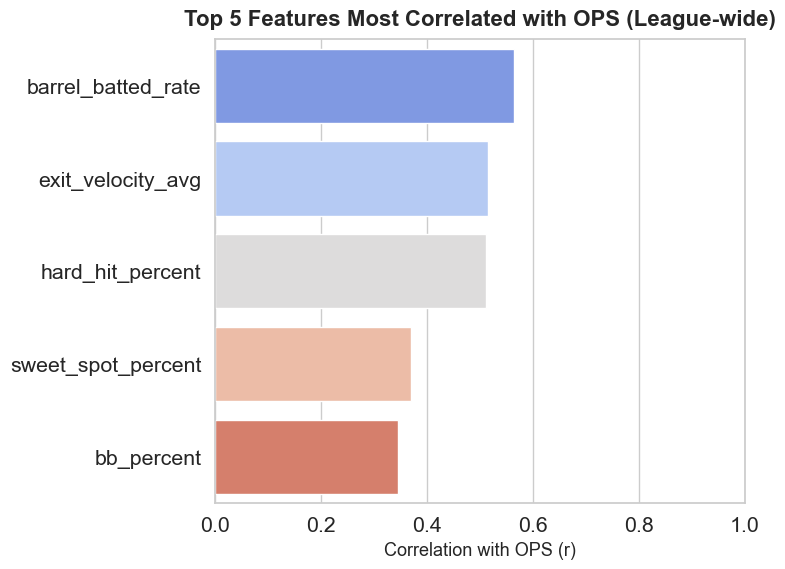


Top 15 Correlations with OPS:
barrel_batted_rate    0.565
exit_velocity_avg     0.515
hard_hit_percent      0.512
sweet_spot_percent    0.370
bb_percent            0.346
dtype: float64


In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 讀取資料 ===
df = pd.read_csv("Project for pand.csv")
df.columns = df.columns.str.strip()  # 清除欄位空白

# === 選擇數值型欄位 ===
num_cols = df.select_dtypes(include=["float", "int"]).columns

# 🧹 排除不分析欄位（避免重複或非打擊指標）
exclude = [
    "player_id", "year",
    "pa", "walk", "hit", "home_run", "strikeout", "double", "triple", "single",
    "batting_avg", "slg_percent", "on_base_percent", "xslg", "woba", "xwoba",
    "avg_swing_speed", "fast_swing_rate", "blasts_contact", "blasts_swing",
    "avg_swing_length", "attack_angle", "ideal_angle_rate",
    "pull_percent", "barrel", "xiso","avg_hyper_speed", "avg_best_speed", "on_base_plus_slg"
]
cols = [c for c in num_cols if c not in exclude]

# === 計算各變數與 OPS 的皮爾森相關係數 ===
corrs = df[cols].corrwith(df["on_base_plus_slg"]).dropna().sort_values(ascending=False)

# === 取前15名顯示 ===
top_corrs = corrs.head(5)

# === 視覺化 ===
plt.figure(figsize=(8, 6))
sns.barplot(
    x=top_corrs.values,
    y=top_corrs.index,
    palette="coolwarm",
    orient="h"
)
plt.title("Top 5 Features Most Correlated with OPS (League-wide)", fontsize=16, weight="bold", pad=10)
plt.xlabel("Correlation with OPS (r)", fontsize=13)
plt.ylabel("")
plt.xlim(0, 1)  # 限定範圍 0~1
plt.tight_layout()
plt.show()

# === 輸出前15項 (純數字表格) ===
print("\nTop 15 Correlations with OPS:")
print(top_corrs.round(3))

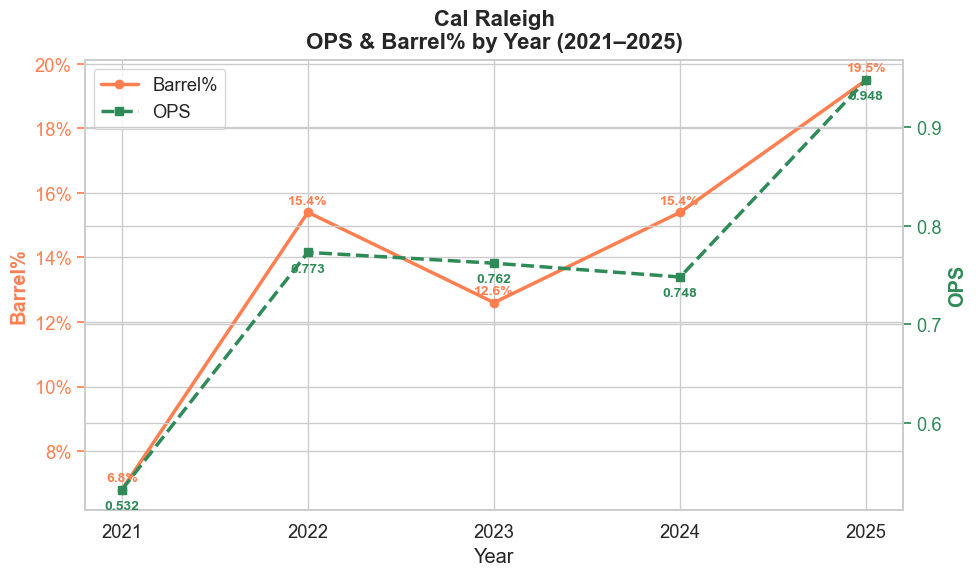

In [147]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# 讀資料
df = pd.read_csv("Project for pand.csv")
df.columns = df.columns.str.strip()

# 目標球員 & 年份
player_id = 663728
p = df[(df["player_id"] == player_id) & (df["year"].between(2021, 2025))].copy()

# 數值轉換
cols = ["year", "barrel_batted_rate", "on_base_plus_slg"]
p[cols] = p[cols].apply(pd.to_numeric, errors="coerce")
p = p.dropna(subset=cols).sort_values("year")

# 若為百分比制（0~100），轉成 0~1
if p["barrel_batted_rate"].mean(skipna=True) > 1:
    p["barrel_batted_rate"] = p["barrel_batted_rate"] / 100.0

# 轉百分比顯示用
p["barrel_pct"] = p["barrel_batted_rate"] * 100

# 繪圖
sns.set(style="whitegrid", font_scale=1.2)
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：Barrel%
line1, = ax1.plot(
    p["year"], p["barrel_pct"],
    marker="o", color="#FF7F50", linewidth=2.5, label="Barrel%"
)
ax1.set_ylabel("Barrel%", color="#FF7F50", weight="bold")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax1.tick_params(axis="y", colors="#FF7F50")

# 右軸：OPS
ax2 = ax1.twinx()
line2, = ax2.plot(
    p["year"], p["on_base_plus_slg"],
    marker="s", color="#2E8B57",
    linestyle="--", linewidth=2.5, label="OPS"
)
ax2.set_ylabel("OPS", color="#2E8B57", weight="bold")
ax2.tick_params(axis="y", colors="#2E8B57")

# 年份刻度（整數；不顯示 .5）
years = sorted(p["year"].unique())
ax1.set_xticks(years)
ax1.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))

# 標註數值
for x, y in zip(p["year"], p["barrel_pct"]):
    ax1.annotate(f"{y:.1f}%", (x, y), textcoords="offset points", xytext=(0, 6),
                 ha="center", fontsize=10, color="#FF7F50", weight="bold")
for x, y in zip(p["year"], p["on_base_plus_slg"]):
    ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, -14),
                 ha="center", fontsize=10, color="#2E8B57", weight="bold")

# 標題與圖例
plt.title("Cal Raleigh\nOPS & Barrel% by Year (2021–2025)",
          fontsize=16, weight="bold", pad=8)
ax1.set_xlabel("Year")

handles = [line1, line2]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

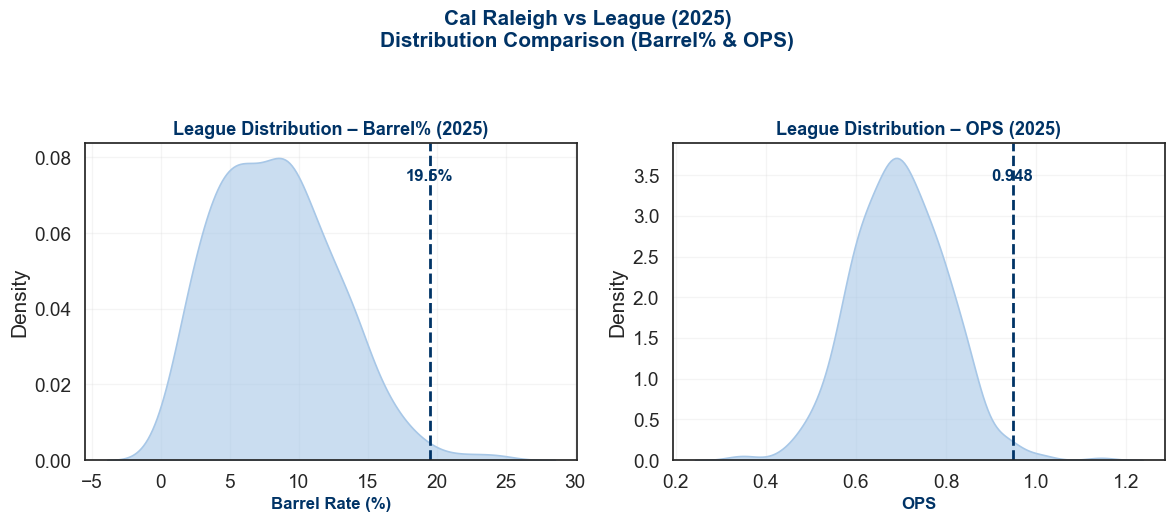

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 讀資料 ---
df = pd.read_csv("Project for pand.csv")
df.columns = df.columns.str.strip()

# --- 篩 Cal Raleigh & 2025 聯盟 ---
cal_id = 663728
year_target = 2025
league_df = df[df["year"] == year_target].copy()
cal_2025 = df[(df["player_id"] == cal_id) & (df["year"] == year_target)].squeeze()

# --- 轉數值 ---
for c in ["barrel_batted_rate", "on_base_plus_slg"]:
    league_df[c] = pd.to_numeric(league_df[c], errors="coerce")
league_df = league_df.dropna(subset=["barrel_batted_rate", "on_base_plus_slg"])

# --- 百分比統一 ---
if league_df["barrel_batted_rate"].mean(skipna=True) > 1:
    league_df["barrel_batted_rate"] /= 100
if pd.to_numeric(cal_2025["barrel_batted_rate"], errors="coerce") > 1:
    cal_2025["barrel_batted_rate"] = float(cal_2025["barrel_batted_rate"]) / 100

# --- 顏色設定（Dashboard 藍色風格） ---
sns.set(style="white", font_scale=1.25)
league_color = "#A7C7E7"     # 淡藍色 KDE（聯盟分布）
highlight_color = "#003366"  # 深藍色虛線（Cal Raleigh）
label_font = dict(fontsize=12, weight="bold", color=highlight_color)

# --- 畫圖 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(wspace=0.25)

## ---- Barrel% KDE ----
bx = league_df["barrel_batted_rate"] * 100
sns.kdeplot(x=bx, fill=True, color=league_color, alpha=0.6, lw=1.2, ax=axes[0])
axes[0].axvline(cal_2025["barrel_batted_rate"] * 100, color=highlight_color, ls="--", lw=2)
axes[0].set_xlabel("Barrel Rate (%)", fontsize=12, weight="bold", color=highlight_color)
axes[0].set_title(f"League Distribution – Barrel% ({year_target})", fontsize=13, weight="bold", color=highlight_color)
axes[0].set_facecolor("white")
axes[0].grid(alpha=0.2)

ymax_b = axes[0].get_ylim()[1]
axes[0].text(
    cal_2025["barrel_batted_rate"] * 100, ymax_b * 0.88,
    f"{cal_2025['barrel_batted_rate'] * 100:.1f}%",
    ha="center", **label_font
)

## ---- OPS KDE ----
sns.kdeplot(x=league_df["on_base_plus_slg"], fill=True, color=league_color, alpha=0.6, lw=1.2, ax=axes[1])
axes[1].axvline(cal_2025["on_base_plus_slg"], color=highlight_color, ls="--", lw=2)
axes[1].set_xlabel("OPS", fontsize=12, weight="bold", color=highlight_color)
axes[1].set_title(f"League Distribution – OPS ({year_target})", fontsize=13, weight="bold", color=highlight_color)
axes[1].set_facecolor("white")
axes[1].grid(alpha=0.2)

ymax_o = axes[1].get_ylim()[1]
axes[1].text(
    cal_2025["on_base_plus_slg"], ymax_o * 0.88,
    f"{cal_2025['on_base_plus_slg']:.3f}",
    ha="center", **label_font
)

# --- 總標題 ---
plt.suptitle(
    f"Cal Raleigh vs League ({year_target})\nDistribution Comparison (Barrel% & OPS)",
    fontsize=15, weight="bold", y=1.05, color=highlight_color
)

plt.tight_layout()
plt.show()

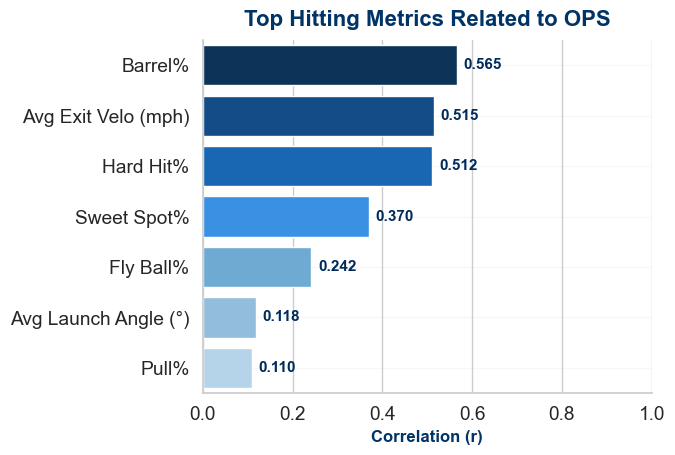

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ========== 1) 讀檔 & 清理 ==========
fn = "Project for pand.csv"
df = pd.read_csv(fn)
df.columns = df.columns.str.strip()

# 目標變數（OPS）
target = "on_base_plus_slg"

# 指標 → 圖上顯示名稱
metrics_map = {
    "barrel_batted_rate": "Barrel%",
    "exit_velocity_avg": "Avg Exit Velo (mph)",
    "hard_hit_percent": "Hard Hit%",
    "sweet_spot_percent": "Sweet Spot%",
    "flyballs_percent": "Fly Ball%",
    "launch_angle_avg": "Avg Launch Angle (°)",
    "pull_percent": "Pull%"
}

cols = list(metrics_map.keys()) + [target]

# 轉數值
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

# 百分比統一（若平均值 > 1）
pct_like = ["barrel_batted_rate", "hard_hit_percent", "sweet_spot_percent",
            "flyballs_percent", "pull_percent"]
for c in pct_like:
    if c in df and df[c].mean(skipna=True) > 1:
        df[c] = df[c] / 100.0

# 去缺值
df = df.dropna(subset=cols)

# ========== 2) 計算與 OPS 的皮爾森相關 ==========
corr = df[list(metrics_map.keys())].corrwith(df[target])
corr = corr[corr > 0]  # 只保留正相關

# 建表 & 排序
corr_df = (
    corr.rename(index=metrics_map)
         .reset_index()
         .rename(columns={"index": "Metric", 0: "Correlation"})
         .sort_values("Correlation", ascending=False)
)

# ========== 3) 視覺化（藍色系） ==========
# 藍色漸層色盤（深藍 → 淺藍）
palette = ["#003366", "#004C99", "#0066CC", "#1E90FF", "#5DADE2", "#85C1E9", "#AED6F1"]

sns.set(style="whitegrid", font_scale=1.25)
fig, ax = plt.subplots(figsize=(7, 4.8))

sns.barplot(
    data=corr_df,
    y="Metric",
    x="Correlation",
    ax=ax,
    palette=palette[:len(corr_df)]
)

# --- 標題與軸 ---
ax.set_title("Top Hitting Metrics Related to OPS", fontsize=16, weight="bold", pad=10, color="#003366")
ax.set_xlabel("Correlation (r)", fontsize=12, weight="bold", color="#003366")
ax.set_ylabel("")
ax.grid(axis="y", which="major", alpha=0.15)

# x軸設定
xmin = 0 if (corr_df["Correlation"] >= 0).all() else min(-1, corr_df["Correlation"].min()*1.1)
xmax = max(1, corr_df["Correlation"].max()*1.05)
ax.set_xlim(xmin, xmax)

# r 值標示
for y, x in enumerate(corr_df["Correlation"].to_list()):
    ax.text(
        x + (xmax - xmin) * 0.015, y,
        f"{x:.3f}",
        va="center", fontsize=11, weight="bold", color="#002B5B"
    )

# 去除上與右邊框，讓風格更乾淨
sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.show()

In [159]:
import pandas as pd

df = pd.read_csv("Project for pand.csv")
df.columns = df.columns.str.strip()

metrics = ["barrel_batted_rate", "exit_velocity_avg", "hard_hit_percent",
            "sweet_spot_percent", "flyballs_percent", "launch_angle_avg", "pull_percent"]

# 確保都是數值
df[metrics + ["on_base_plus_slg"]] = df[metrics + ["on_base_plus_slg"]].apply(pd.to_numeric, errors="coerce")

# 移除空值
df = df.dropna(subset=metrics + ["on_base_plus_slg"])

# 計算相關係數
corrs = df[metrics].corrwith(df["on_base_plus_slg"]).sort_values(ascending=False)
print(corrs)

barrel_batted_rate    0.565338
exit_velocity_avg     0.515083
hard_hit_percent      0.511521
sweet_spot_percent    0.369690
flyballs_percent      0.241997
launch_angle_avg      0.117607
pull_percent          0.109655
dtype: float64


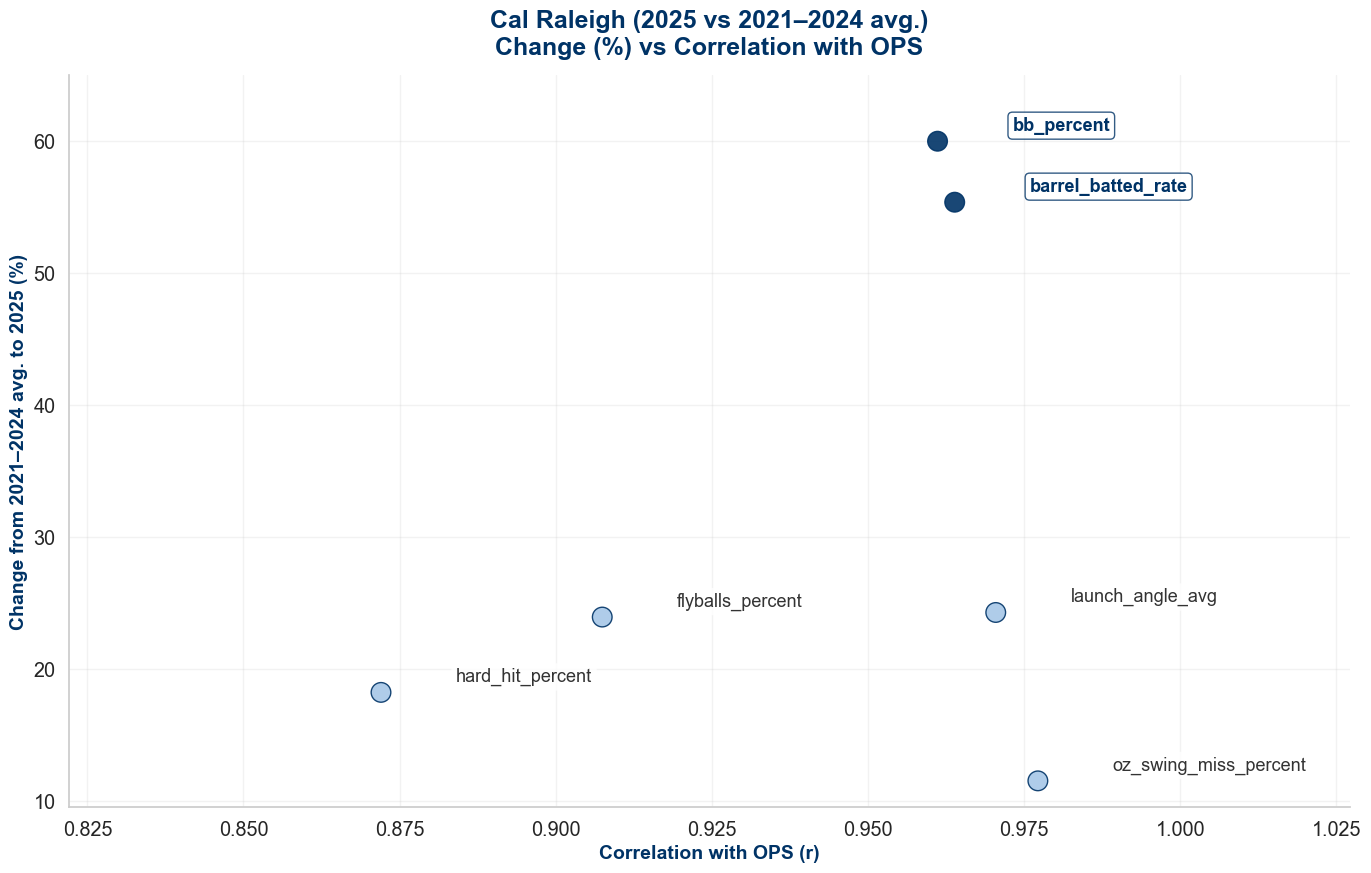

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 讀取資料 ---
df = pd.read_csv("Project for pand.csv")

# --- 篩選 Cal Raleigh ---
player_df = df[df["player_id"] == 663728].copy()
player_df = player_df[player_df["year"].between(2021, 2025)]

# --- 數值欄位 ---
num_cols = player_df.select_dtypes(include=["float", "int"]).columns

# 🧹 排除不分析欄位 ---
exclude = [
    "player_id", "year",
    "pa", "walk", "hit", "home_run", "strikeout", "double", "triple", "single",
    "batting_avg", "slg_percent", "on_base_percent", "xslg", "woba", "xwoba",
    "avg_swing_speed", "fast_swing_rate", "blasts_contact", "blasts_swing",
    "avg_swing_length", "attack_angle", "ideal_angle_rate",
    "pull_percent", "barrel", "xiso", "on_base_plus_slg"
]
cols = [c for c in num_cols if c not in exclude]

# --- 計算平均與變化 ---
df_avg = player_df[player_df["year"].between(2021, 2024)][cols].mean()
df_2025 = player_df[player_df["year"] == 2025][cols].mean()
diff = ((df_2025 - df_avg) / df_avg * 100).sort_values(ascending=False)

# --- 與 OPS 的相關 ---
corrs = player_df[cols].corrwith(player_df["on_base_plus_slg"])
corrs = corrs[corrs > 0].sort_values(ascending=False)

# --- 合併 ---
compare = pd.DataFrame({
    "corr_with_OPS": corrs,
    "change_2025_minus_avg21_24(%)": diff[corrs.index]
}).dropna().sort_values("change_2025_minus_avg21_24(%)", ascending=False)

# ✅ 篩掉變化 < 10% 的欄位
compare = compare[compare["change_2025_minus_avg21_24(%)"] >= 10]

# --- 顏色設定 ---
sns.set(style="whitegrid", font_scale=1.3)
fig, ax = plt.subplots(figsize=(14, 9))

# 🎯 指定高亮變數
highlight_vars = ["bb_percent", "barrel_batted_rate"]

# 動態顏色設定：高亮深藍，其他淡藍
colors = [
    "#003366" if var in highlight_vars else "#A7C7E7"
    for var in compare.index
]

# --- 散點繪製 ---
points = ax.scatter(
    compare["corr_with_OPS"],
    compare["change_2025_minus_avg21_24(%)"],
    c=colors,
    s=200,
    edgecolor="#003366",
    linewidth=1,
    alpha=0.9
)

# --- 標籤文字 ---
for i, var in enumerate(compare.index):
    label_color = "#003366" if var in highlight_vars else "#333333"
    font_weight = "bold" if var in highlight_vars else "normal"
    bbox_style = dict(
        facecolor='white', alpha=0.8,
        edgecolor='#003366' if var in highlight_vars else 'none',
        boxstyle='round,pad=0.25'
    )

    ax.text(
        compare["corr_with_OPS"].iloc[i] + 0.012,
        compare["change_2025_minus_avg21_24(%)"].iloc[i] + 0.8,
        var,
        fontsize=13, weight=font_weight, color=label_color,
        bbox=bbox_style
    )

# --- 輔助線 ---
ax.axvline(0, color="#AAB7B8", linestyle="--", linewidth=1.2)
ax.axhline(0, color="#AAB7B8", linestyle="--", linewidth=1.2)

# ✅ 讓橫軸不從 0 開始，從最小值 -0.05 起
x_min = compare["corr_with_OPS"].min() - 0.05
x_max = compare["corr_with_OPS"].max() + 0.05
ax.set_xlim(x_min, x_max)

# ✅ Y 軸從 10% 開始
y_min = compare["change_2025_minus_avg21_24(%)"].min() - 2
ax.set_ylim(y_min, compare["change_2025_minus_avg21_24(%)"].max() + 5)

# --- 標題與軸設定 ---
ax.set_title(
    "Cal Raleigh (2025 vs 2021–2024 avg.)\nChange (%) vs Correlation with OPS",
    fontsize=18, weight="bold", color="#003366", pad=15
)
ax.set_xlabel("Correlation with OPS (r)", fontsize=14, weight="bold", color="#003366")
ax.set_ylabel("Change from 2021–2024 avg. to 2025 (%)", fontsize=14, weight="bold", color="#003366")
ax.grid(alpha=0.25)

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()